# Лекція 13 — Самонавчання

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 13  
**Тема лабораторної:** Самонавчання

**Ключова ідея:** мітки — коштовний ресурс. Але самі дані вже містять
надзвичайно багато інформації. Самонавчання — це мистецтво витягувати
цю інформацію без жодної розмітки.

## Цілі лекції
- [Мотивація: навчання без міток](#motivation) 
- [Автоенкодери як самоконтроль](#autoencoders) 
- [Denoising як сильніший сигнал](#denoising) 
- [Псевдо-мітки та Self-Training](#pseudo) 
- [Контрастивне навчання](#contrastive) 
- [Зв'язок із сучасними моделями](#modern) 
- [Підсумок](#summary) 


### Налаштування середовища

Датасет цієї лекції — **digits** із sklearn: 1797 зображень цифр 0–9
розміром 8×8 = 64 пікселі. Завантажується миттєво, навчається за секунди
на CPU, і студенти вже добре знайомі з ним із попередніх лекцій.

Класи автоенкодерів (`Autoencoder`, `DenoisingAutoencoder`, `train_autoencoder`,
`reconstruction_error`) імпортуються з модуля лабораторної роботи 12.
Архітектура і нотація залишаються незмінними.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import importlib
import warnings
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE as COLORS
setup_plot_style()

from autoencoder_student import (
    Encoder, Autoencoder, DenoisingAutoencoder,
    train_autoencoder, reconstruction_error,
)

In [2]:
# Load and normalise: pixel values are integers 0-16, scale to [0, 1]
digits = load_digits()
X_all  = digits.data.astype(np.float32) / 16.0
y_all  = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
)

# Autoencoder dimensions (same as lecture week 11 on digits)
INPUT_DIM  = 64
HIDDEN_DIM = 128
LATENT_DIM = 8

print(f'Train : {X_tr.shape}   Test : {X_te.shape}')
print(f'Pixel range : [{X_all.min():.2f}, {X_all.max():.2f}]')

Train : (1437, 64)   Test : (360, 64)
Pixel range : [0.00, 1.00]


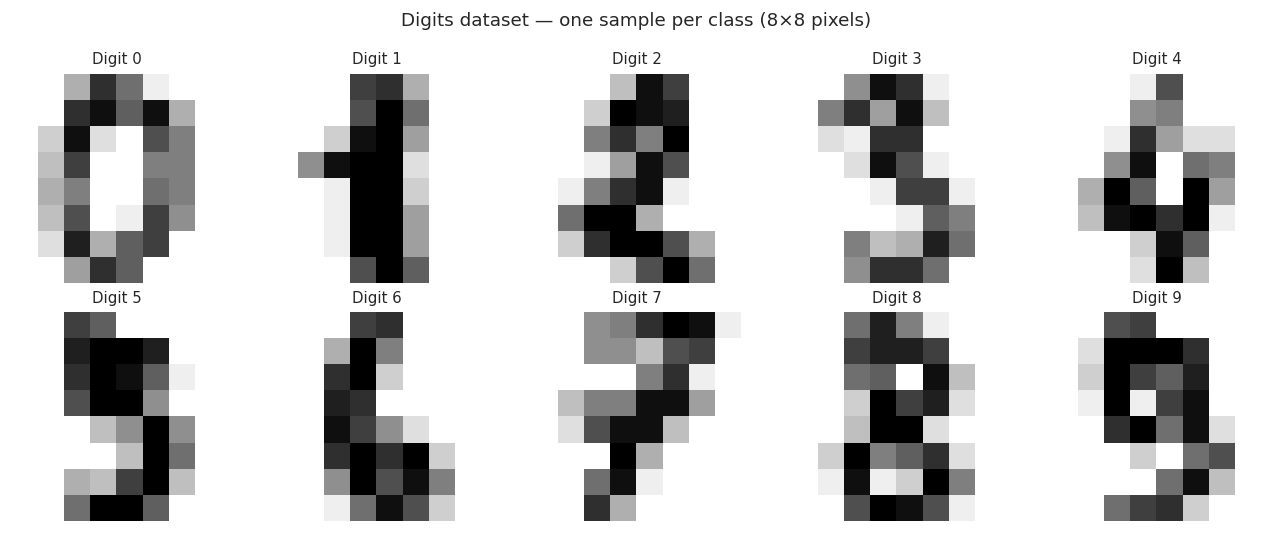

In [3]:
# Visualise one sample per class
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for c, ax in zip(range(10), axes.flat):
    sample = X_all[y_all == c][0].reshape(8, 8)
    ax.imshow(sample, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f'Digit {c}', fontsize=9)
    ax.axis('off')
plt.suptitle('Digits dataset — one sample per class (8×8 pixels)', fontsize=11)
plt.tight_layout()
plt.show()

---
<a id='motivation'></a>
## 1. Мотивація: навчання без міток

### 1.1 Чому мітки дорогі

Більшість алгоритмів, розглянутих у цьому курсі, потребує розмічених
прикладів $(x_i, y_i)$. Але розмітка — дорога:

| Задача | Що потрібно від людини | Орієнтовний час |
|--------|------------------------|-----------------|
| Класифікація медичних знімків | Висновок лікаря-фахівця | 5–60 хв |
| Sentiment analysis | Оцінка анотатора | 30–60 с |
| Object detection (bounding box) | Обведення об'єктів вручну | 1–10 хв |
| Машинний переклад | Людина-перекладач | лінійно з довжиною |

Водночас нерозмічених даних — мільярди. Інтернет генерує за добу
більше тексту й зображень, ніж людство здатне розмітити за рік.

**Self-supervised learning** — сімейство методів, що перетворює
**структуру самих даних** на сигнал для навчання, без жодної людської розмітки.

### 1.2 Що дає кожна нова мітка?

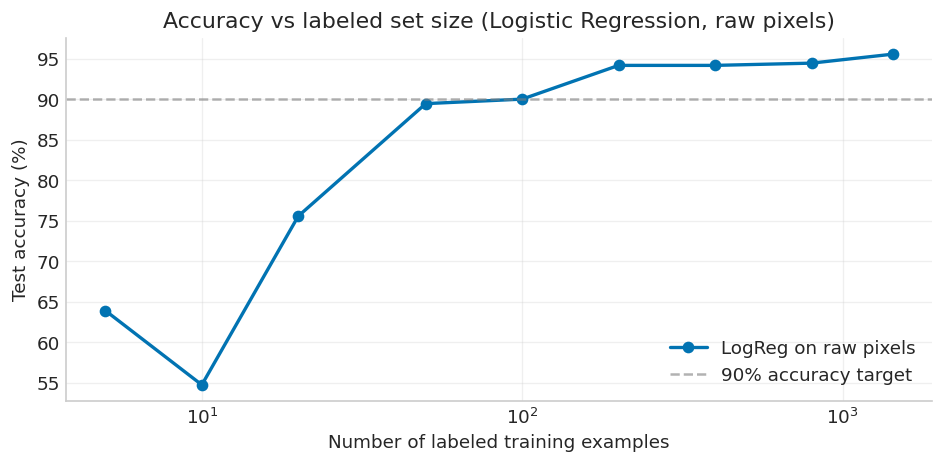

100 labeled : 90.0%   All 1437 labeled : 95.6%


In [4]:
# Show how accuracy degrades as the labeled training set shrinks.
# We test LogisticRegression on raw pixels at various labeled set sizes.

labeled_sizes = [5, 10, 20, 50, 100, 200, 400, 800, len(X_tr)]
accs_labeled  = []

rng0 = np.random.RandomState(SEED)
for n in labeled_sizes:
    if n >= len(X_tr):
        idx = np.arange(len(X_tr))
    else:
        # Stratified: take n//10 samples per class
        idx = []
        for c in range(10):
            c_idx = np.where(y_tr == c)[0]
            take  = max(1, n // 10)
            idx.extend(rng0.choice(c_idx, size=min(take, len(c_idx)), replace=False))
        idx = np.array(idx)

    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(X_tr[idx], y_tr[idx])
    accs_labeled.append(accuracy_score(y_te, clf.predict(X_te)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(labeled_sizes, [a * 100 for a in accs_labeled],
        marker='o', color=COLORS[0], lw=2, markersize=6, label='LogReg on raw pixels')
ax.axhline(90, linestyle='--', color='gray', alpha=0.6, label='90% accuracy target')
ax.set_xlabel('Number of labeled training examples')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Accuracy vs labeled set size (Logistic Regression, raw pixels)')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'100 labeled : {accs_labeled[4]:.1%}   All {len(X_tr)} labeled : {accs_labeled[-1]:.1%}')

**Спостереження:** при 100 мітках точність вже непогана (~85–90%),
але суттєво поступається повній вибірці. Задача self-supervised learning —
скоротити цей розрив: навчитись корисним представленням **без міток**,
щоб навіть невелика кількість розмічених прикладів давала хорошу точність.

### 1.3 Що таке pretext task?

**Pretext task** (допоміжна задача) — штучно сконструйована задача,
відповідь на яку генерується **автоматично зі структури даних**
без участі людини. Розв'язуючи її, модель змушена вивчити корисне
внутрішнє представлення.

$$\text{pretext task}: \quad \text{дані} \;\xrightarrow{\text{автоматично}}\; \text{цільовий сигнал}$$

Приклади pretext tasks, які ми розглянемо в цій лекції:

| Метод | Pretext task | Як генерується сигнал |
|-------|-------------|----------------------|
| Autoencoder | Реконструюй вхід | $\|x - \hat{x}\|^2$ — сам $x$ є ціллю |
| Denoising AE | Відновити $x$ із $\tilde{x} = x + \varepsilon$ | Шум генерується автоматично |
| Self-training | Класифікуй нерозмічені через власні передбачення | Confident прогнози моделі |
| Contrastive | Розрізнити два погляди на один приклад | Аугментації генеруються автоматично |

---
<a id='autoencoders'></a>
## 2. Автоенкодери як форма самоконтролю

В 12 лабораторній роботі ми детально реалізували та навчили автоенкодери.
Тут переосмислюємо їх із точки зору self-supervised learning.

### 2.1 Архітектура та pretext task

```
x (64D)  →  Encoder  →  z (8D)  →  Decoder  →  x̂ (64D)
```

Функція втрат:

$$\mathcal{L}_{\text{AE}} = \frac{1}{n}\sum_{i=1}^{n}\|x_i - \hat{x}_i\|^2$$

Зверніть увагу: у цій функції **немає міток класів**. Єдиний сигнал —
сам вхід $x$. Автоенкодер є повноправним алгоритмом self-supervised learning.

Під час навчання модель вирішує задачу стиснення: зберегти у векторі
$z \in \mathbb{R}^8$ лише ту інформацію, яка потрібна для реконструкції.
Якщо $z$ добре описує структуру даних, то **лінійний класифікатор** поверх $z$
зможе розрізняти класи навіть без того, щоб автоенкодер знав про їхнє існування.

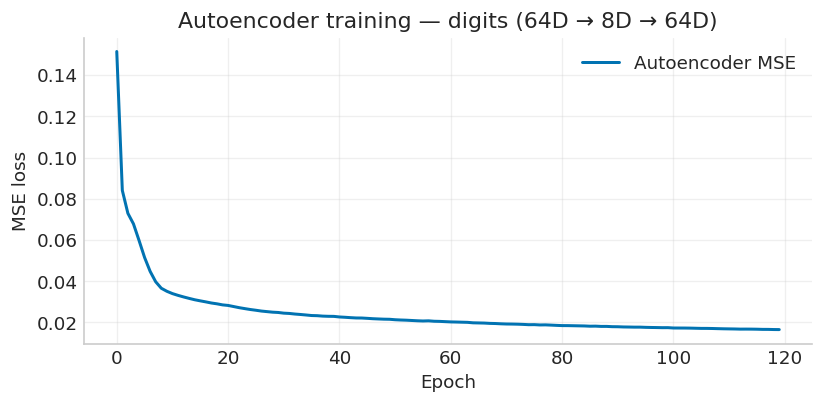

Initial loss : 0.1514   Final loss : 0.0165


In [5]:
torch.manual_seed(SEED)
ae = Autoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
ae_losses = train_autoencoder(ae, X_tr, n_epochs=120, lr=1e-3, batch_size=64, seed=SEED)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ae_losses, color=COLORS[0], lw=1.8, label='Autoencoder MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Autoencoder training — digits (64D → 8D → 64D)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Initial loss : {ae_losses[0]:.4f}   Final loss : {ae_losses[-1]:.4f}')

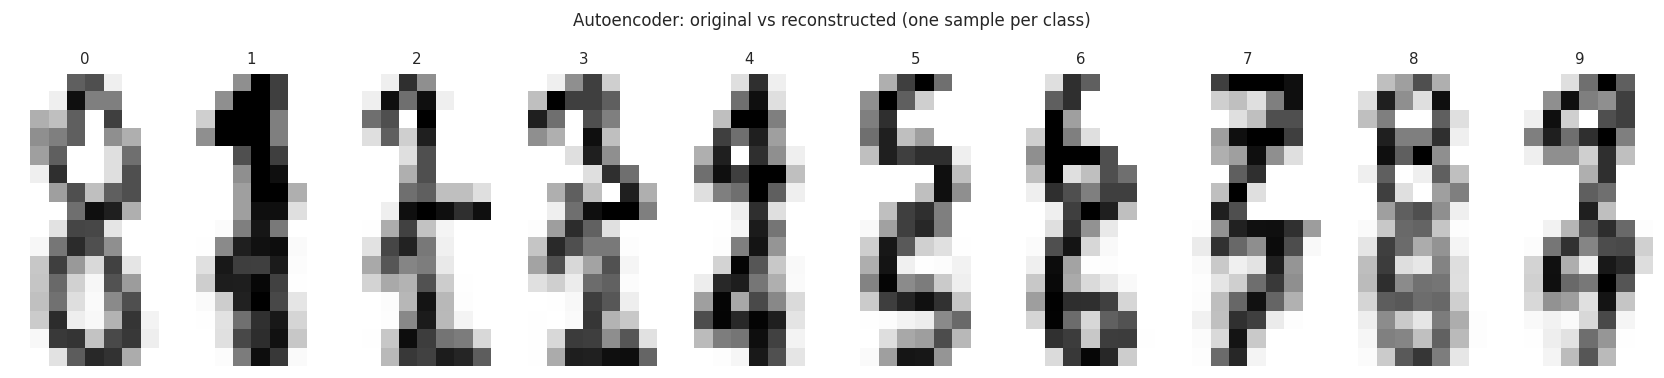

In [6]:
# Pick one test sample per class for reconstruction visualisation
rng1     = np.random.RandomState(1)
show_idx = np.array([rng1.choice(np.where(y_te == c)[0]) for c in range(10)])

X_show = X_te[show_idx]
ae.eval()
with torch.no_grad():
    X_recon = ae(torch.tensor(X_show, dtype=torch.float32)).numpy()

fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for col in range(10):
    for row, data in enumerate([X_show, X_recon]):
        axes[row, col].imshow(data[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(str(col), fontsize=9)

axes[0, 0].set_ylabel('Original',     fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.suptitle('Autoencoder: original vs reconstructed (one sample per class)', fontsize=10)
plt.tight_layout()
plt.show()

**Спостереження:** реконструкція виглядає правдоподібно попри стиснення
у 8 разів (64D → 8D). Модель зберегла основні риси кожної цифри.

### 2.2 Лінійний зонд

**Лінійний зонд (linear probe):** навчити логістичну регресію поверх
заморожених векторів $z$ (ваги автоенкодера не оновлюються).
Якщо точність висока — представлення **лінійно відокремлює** класи
без додаткового навчання.

Ми порівняємо два варіанти:

| Вхід до класифікатора | Розмірність | Доступ до міток під час навчання |
|-----------------------|-------------|----------------------------------|
| Сирі пікселі | 64D | Ні |
| AE латентний код $z$ | 8D | Ні |

In [7]:
ae.eval()
with torch.no_grad():
    Z_ae_tr = ae.encode(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    Z_ae_te = ae.encode(torch.tensor(X_te, dtype=torch.float32)).numpy()

def linear_probe(Z_tr, Z_te, y_tr_, y_te_, name):
    """Train LogReg on frozen representations, report train and test accuracy."""
    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(Z_tr, y_tr_)
    tr_acc = accuracy_score(y_tr_, clf.predict(Z_tr))
    te_acc = accuracy_score(y_te_, clf.predict(Z_te))
    print(f'{name:<38} train: {tr_acc:.1%}   test: {te_acc:.1%}')
    return te_acc

print(f'{"Representation":<38} {"Train":>10}   {"Test":>8}')
print('-' * 64)
acc_raw = linear_probe(X_tr,    X_te,    y_tr, y_te, 'Raw pixels (64D)')
acc_ae  = linear_probe(Z_ae_tr, Z_ae_te, y_tr, y_te, 'AE latent z (8D)')

Representation                              Train       Test
----------------------------------------------------------------
Raw pixels (64D)                       train: 98.7%   test: 95.6%
AE latent z (8D)                       train: 92.2%   test: 88.9%


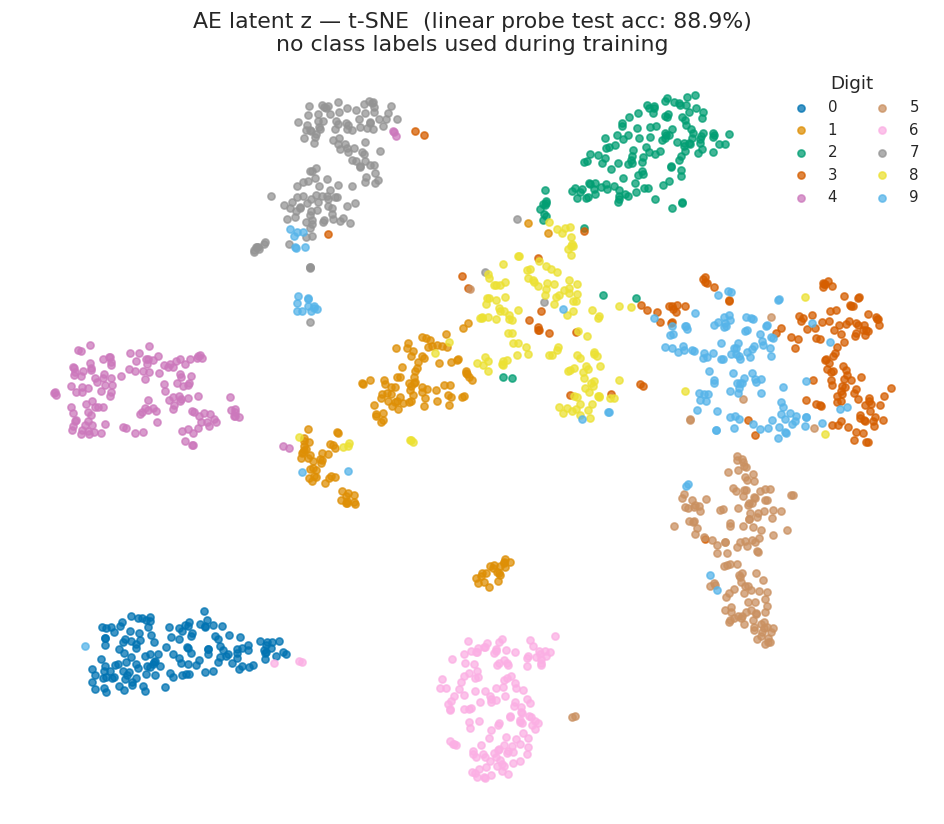

In [10]:
# Visualise the latent space with t-SNE
tsne_kw = dict(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
scaler  = StandardScaler()

Y_ae = TSNE(**tsne_kw).fit_transform(scaler.fit_transform(Z_ae_tr))

fig, ax = plt.subplots(figsize=(8, 7))
for c, col in zip(range(10), COLORS):
    mask = y_tr == c
    ax.scatter(Y_ae[mask, 0], Y_ae[mask, 1],
               color=col, label=str(c), s=18, alpha=0.75)
ax.set_title(
    f'AE latent z — t-SNE  (linear probe test acc: {acc_ae:.1%})\n'
    'no class labels used during training'
)
ax.legend(title='Digit', fontsize=9, ncol=2)
ax.axis('off')
plt.tight_layout()
plt.show()

**Ключовий висновок:** автоенкодер **без жодної мітки** організував
латентний простір так, що цифри різних класів здебільшого відокремлені.
Це self-supervised learning у дії: сигнал реконструкції змусив модель
вивчити структуру даних.

---
<a id='denoising'></a>
## 3. Denoising як сильніший pretext task

### 3.1 Ідея

Стандартний автоенкодер відновлює **той самий** вхід, що отримав.
Це «легке» завдання: модель може «обдурити» задачу, не навчаючись
нічому корисному (наприклад, просто запам'ятати тренувальні приклади).

**Denoising Autoencoder (DAE)** ускладнює задачу:

$$\mathcal{L}_{\text{DAE}} = \|x - f(\tilde{x})\|^2,
\qquad \tilde{x} = \text{clip}(x + \varepsilon,\, 0, 1), \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

Модель отримує **зашумлений** вхід $\tilde{x}$, але має відновити **чистий** $x$.
Щоб це зробити успішно, вона змушена вивчити, де у просторі знаходяться
«справжні» дані.

### 3.2 Зв'язок із BERT

Ця ж ідея лежить в основі BERT (Devlin et al., 2018):

> «Замаскуй 15% токенів у реченні → попроси модель відновити їх.»

Маскування у BERT — це навмисне ушкодження входу, реконструкція — pretext task.
**Принцип рівно той самий**, що у DAE, але застосований до мови.

| Модель | Що ушкоджується | Що відновлюється | Функція втрат |
|--------|----------------|-----------------|---------------|
| DAE (зображення) | Пікселі + гаусовий шум | Чисте зображення | MSE |
| BERT (текст) | 15% токенів → `[MASK]` | Оригінальні токени | Cross-entropy |
| MAE (зображення, 2021) | 75% патчів → порожньо | Відсутні патчі | MSE |

In [11]:
torch.manual_seed(SEED)
dae = DenoisingAutoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM, noise_std=0.35
)
dae_losses = train_autoencoder(dae, X_tr, n_epochs=120, lr=1e-3, batch_size=64, seed=SEED)
print(f'DAE final loss: {dae_losses[-1]:.4f}')

DAE final loss: 0.0279


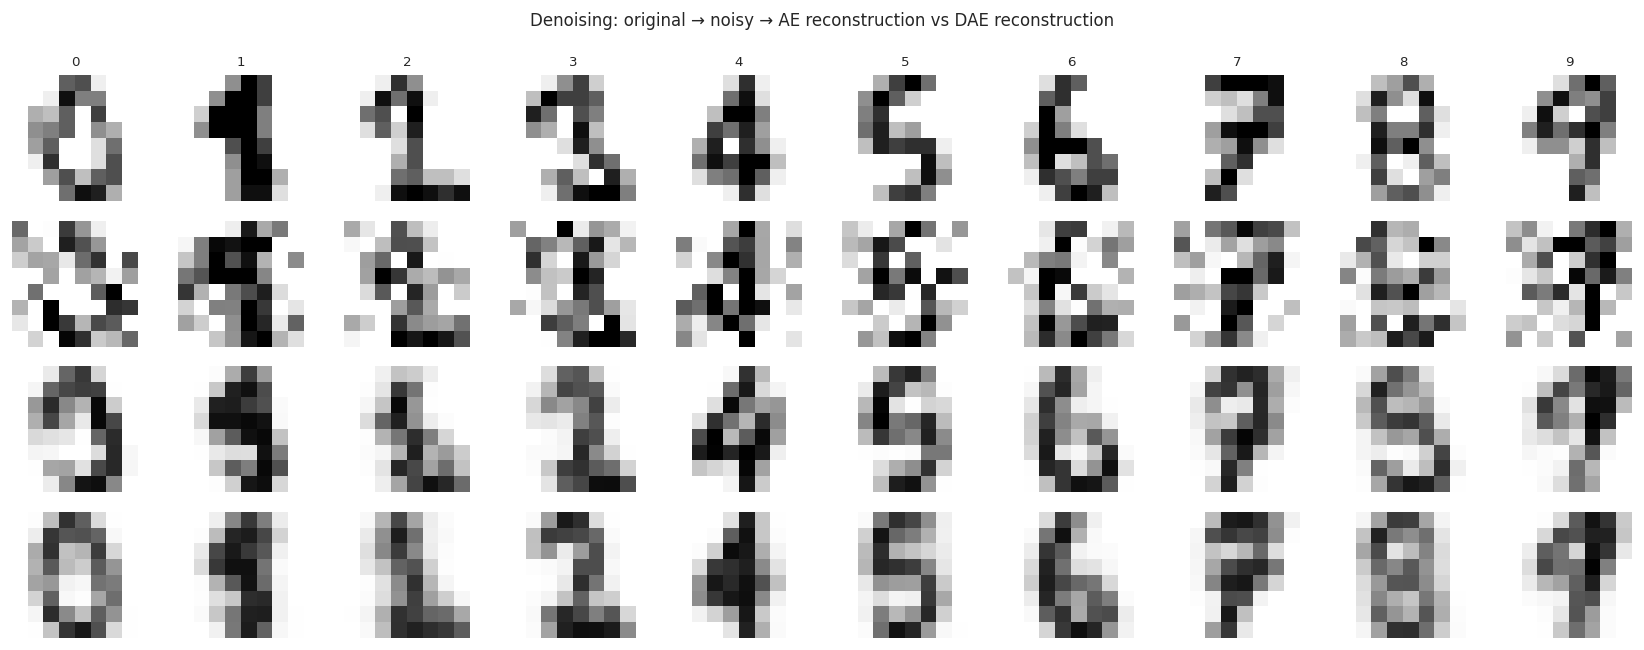

In [12]:
# Visualise: original -> noisy -> AE reconstruction -> DAE reconstruction
noise_std_vis = 0.35
rng2 = np.random.RandomState(7)

X_show_noisy = np.clip(
    X_show + rng2.randn(*X_show.shape) * noise_std_vis, 0, 1
).astype(np.float32)

ae.eval(); dae.eval()
with torch.no_grad():
    t_noisy     = torch.tensor(X_show_noisy, dtype=torch.float32)
    X_ae_recon  = ae(t_noisy).numpy()
    X_dae_recon = dae(t_noisy).numpy()

row_data   = [X_show, X_show_noisy, X_ae_recon, X_dae_recon]
row_labels = ['Original', f'Noisy  (σ={noise_std_vis})', 'AE recon', 'DAE recon']

fig, axes = plt.subplots(4, 10, figsize=(14, 5.5))
for row, (data, label) in enumerate(zip(row_data, row_labels)):
    for col in range(10):
        axes[row, col].imshow(data[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=8)
    if row == 0:
        for col in range(10):
            axes[row, col].set_title(str(col), fontsize=8)

plt.suptitle('Denoising: original → noisy → AE reconstruction vs DAE reconstruction', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Linear probe: add DAE to the comparison
dae.eval()
with torch.no_grad():
    Z_dae_tr = dae.encode(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    Z_dae_te = dae.encode(torch.tensor(X_te, dtype=torch.float32)).numpy()

print(f'{"Representation":<38} {"Train":>10}   {"Test":>8}')
print('-' * 64)
acc_raw = linear_probe(X_tr,     X_te,     y_tr, y_te, 'Raw pixels (64D)')
acc_ae  = linear_probe(Z_ae_tr,  Z_ae_te,  y_tr, y_te, 'AE  latent z (8D)')
acc_dae = linear_probe(Z_dae_tr, Z_dae_te, y_tr, y_te, 'DAE latent z (8D)')

Representation                              Train       Test
----------------------------------------------------------------
Raw pixels (64D)                       train: 98.7%   test: 95.6%
AE  latent z (8D)                      train: 92.2%   test: 88.9%
DAE latent z (8D)                      train: 92.1%   test: 91.4%


**Спостереження:**

DAE, як правило, дає кращу точність лінійного зонду, ніж стандартний AE.
Причина: ускладнений pretext task змушує модель вивчити більш «загальне»
та стабільне представлення — таке, що не спирається на окремі пікселі,
а схоплює форму цифри в цілому.

На Fashion-MNIST (лабораторна 12) різниця між AE і DAE була менш виразна,
бо коефіцієнт стиснення 49× (784→16) уже сам по собі є надто суворим.
На digits (64→8, коефіцієнт 8×) представлення багатше, і перевага DAE
проявляється чіткіше.

---
<a id='pseudo'></a>
## 4. Псевдо-мітки та Self-Training

### 4.1 Зв'язок із представленнями AE

У Розділах 2–3 автоенкодер навчився на **всіх** 1437 тренувальних
зображеннях без жодної мітки і перетворив кожне із них на вектор
$z \in \mathbb{R}^8$. Ці вектори вже добре відокремлюють класи
(ми перевірили це лінійним зондом у Розділі 2.2).

Тепер розглянемо реалістичніший сценарій:

> Уяви, що ти щойно зібрав 1437 зображень і маєш **бюджет розмітки
> лише на 100 прикладів** (10 на клас). Решта 1337 — нерозмічені.

Два кроки, які ми вже знаємо:

1. **Крок 1 (Розділ 2):** навчити AE на всіх 1437 зображеннях без міток → отримати $Z_{\text{ae}}$.
2. **Крок 2 (Розділ 2.2):** навчити лінійний класифікатор на 100 розмічених $z$ → baseline.

**Крок 3 — Self-Training** (цей розділ): використати впевнені
передбачення класифікатора на нерозмічених $z$ як псевдо-мітки,
щоб розширити тренувальну вибірку.

### 4.2 Алгоритм

```
Дано: Z_lab (100 розмічених латентних кодів)
       Z_pool (1337 нерозмічених латентних кодів)

Крок 0. Навчити LogReg на Z_lab  (той самий linear probe з Розділу 2.2)
Крок 1. Для кожного z ∈ Z_pool обчислити P(y | z)
         Відібрати ті z, де max P(y|z) > θ
         Призначити ŷ = argmax P(y|z)
         Видалити відібрані z з пулу  ← важливо: кожен z додається лише раз
Крок 2. Додати (z, ŷ) до Z_lab; перенавчити LogReg
Крок 3. Повторити кроки 1–2
```

### 4.3 Ключовий ризик: error propagation

Якщо поріг $\theta$ занадто низький, до тренувального набору потрапляють
хибно-впевнені псевдо-мітки. Ці помилки закріплюються і накопичуються
від раунду до раунду. Колонка `pseudo accuracy` у виводі нижче
показує, скільки прийнятих псевдо-міток є правильними.

In [40]:
# Simulate the semi-supervised setting: only N_LABELED examples are annotated.
# The AE was already trained on ALL 1437 samples without labels (Section 2),
# so Z_ae_tr is available for every training sample — labeled or not.
N_LABELED = 100   # 100 out of 1437 = 7%

rng3 = np.random.RandomState(SEED)
lab_idx = []
for c in range(10):
    c_idx = np.where(y_tr == c)[0]
    lab_idx.extend(rng3.choice(c_idx, size=N_LABELED // 10, replace=False))
lab_idx    = np.array(lab_idx)

unlab_mask = np.ones(len(X_tr), dtype=bool)
unlab_mask[lab_idx] = False
unlab_idx  = np.where(unlab_mask)[0]

# Use AE latent codes as features — the same representation from Section 2
Z_lab    = Z_ae_tr[lab_idx];   y_lab    = y_tr[lab_idx]
Z_unlab  = Z_ae_tr[unlab_idx]; y_unlab  = y_tr[unlab_idx]  # labels hidden from the model

print(f'Labeled   : {len(Z_lab)} latent vectors  (labels visible)')
print(f'Unlabeled : {len(Z_unlab)} latent vectors  (labels hidden)')
print(f'Test      : {len(Z_ae_te)} latent vectors')

Labeled   : 100 latent vectors  (labels visible)
Unlabeled : 1337 latent vectors  (labels hidden)
Test      : 360 latent vectors


In [41]:
# --- Self-training: two threshold variants ---
THRESHOLD  = 0.98   # high threshold: fewer but reliable pseudo-labels
MAX_ROUNDS = 5

# --- Round 0: linear probe on 100 labeled latent codes ---
# Same classifier as in Section 2.2; now trained on only 100 samples
clf = LogisticRegression(max_iter=500, random_state=SEED)
clf.fit(Z_lab, y_lab)
acc0 = accuracy_score(y_te, clf.predict(Z_ae_te))
print(f'Round 0 — 100 labeled latent codes:  test acc = {acc0:.1%}')

# --- Self-training loop ---
# Z_pool shrinks each round: every accepted sample is removed so it can't be added again
history = [{'round': 0, 'acc': acc0, 'n_train': N_LABELED, 'n_pseudo': 0}]

Z_cur   = Z_lab.copy()
y_cur   = y_lab.copy()
Z_pool  = Z_unlab.copy()           # shrinks over rounds
y_pool  = y_unlab.copy()           # hidden ground truth, used only for pseudo_acc reporting

for rnd in range(1, MAX_ROUNDS + 1):
    probs  = clf.predict_proba(Z_pool)       # probabilities over 10 classes
    conf   = probs.max(axis=1)               # confidence = max class probability
    labels = probs.argmax(axis=1)            # hard pseudo-label

    accept = conf >= THRESHOLD
    n_acc  = accept.sum()
    if n_acc == 0:
        print(f'Round {rnd}: pool exhausted at θ={THRESHOLD}. Stopping.')
        break

    pseudo_acc = accuracy_score(y_pool[accept], labels[accept])  # vs hidden truth

    # Add accepted pseudo-labeled samples to training set
    Z_cur  = np.concatenate([Z_cur, Z_pool[accept]])
    y_cur  = np.concatenate([y_cur, labels[accept]])

    # Deplete pool — each sample can only be added once
    Z_pool = Z_pool[~accept]
    y_pool = y_pool[~accept]

    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(Z_cur, y_cur)
    acc = accuracy_score(y_te, clf.predict(Z_ae_te))

    history.append({
        'round': rnd, 'acc': acc,
        'n_train': len(Z_cur), 'n_pseudo': n_acc,
        'pseudo_acc': pseudo_acc,
    })
    print(
        f'Round {rnd}: accepted {n_acc:4d} pseudo-labels '
        f'(pseudo acc={pseudo_acc:.1%}),  '
        f'pool remaining={len(Z_pool)},  test acc={acc:.1%}'
    )

# Oracle: linear probe trained on all 1437 labeled latent codes
clf_oracle = LogisticRegression(max_iter=500, random_state=SEED)
clf_oracle.fit(Z_ae_tr, y_tr)
acc_oracle = accuracy_score(y_te, clf_oracle.predict(Z_ae_te))

Round 0 — 100 labeled latent codes:  test acc = 84.7%
Round 1: accepted  284 pseudo-labels (pseudo acc=100.0%),  pool remaining=1053,  test acc=85.8%
Round 2: accepted  115 pseudo-labels (pseudo acc=100.0%),  pool remaining=938,  test acc=85.8%
Round 3: accepted   48 pseudo-labels (pseudo acc=100.0%),  pool remaining=890,  test acc=86.1%
Round 4: accepted   32 pseudo-labels (pseudo acc=100.0%),  pool remaining=858,  test acc=86.4%
Round 5: accepted   13 pseudo-labels (pseudo acc=92.3%),  pool remaining=845,  test acc=85.6%


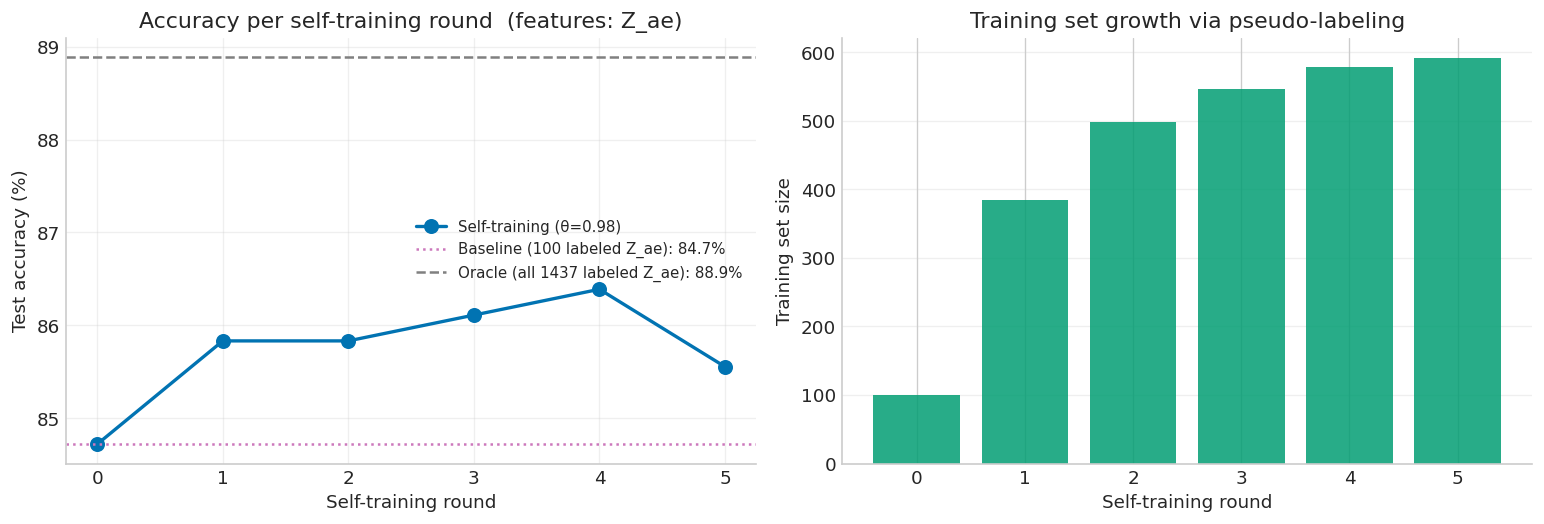

In [42]:
# Plot self-training progress
rounds   = [h['round']   for h in history]
accs_st  = [h['acc']     for h in history]
n_trains = [h['n_train'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(rounds, [a * 100 for a in accs_st],
         marker='o', color=COLORS[0], lw=2, markersize=8, label=f'Self-training (θ={THRESHOLD})')
ax1.axhline(acc0 * 100, linestyle=':', color=COLORS[4], lw=1.5,
            label=f'Baseline (100 labeled Z_ae): {acc0:.1%}')
ax1.axhline(acc_oracle * 100, linestyle='--', color='gray', lw=1.5,
            label=f'Oracle (all {len(X_tr)} labeled Z_ae): {acc_oracle:.1%}')
ax1.set_xlabel('Self-training round')
ax1.set_ylabel('Test accuracy (%)')
ax1.set_title('Accuracy per self-training round  (features: Z_ae)')
ax1.set_xticks(rounds)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.bar([str(r) for r in rounds], n_trains, color=COLORS[2], alpha=0.85)
ax2.set_xlabel('Self-training round')
ax2.set_ylabel('Training set size')
ax2.set_title('Training set growth via pseudo-labeling')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Спостереження:**

 - **Раунди 1–4:** точність стабільно зростає з 84.7% до ~86.6% —
   псевдо-мітки мають високу якість, і кожен новий раунд корисний.
 - **Раунд 5:** точність дещо спадає, і це не випадково. З кожним
   раундом пул скорочується: «легкі» зразки (далеко від меж класів)
   вже прийняті. Залишаються складніші зразки поблизу меж рішень,
   де модель менш надійна — звідси нижча `pseudo accuracy` і перший
   прояв **error propagation**.
 - **Пул виснажується повільно** (100 → ~600 за 5 раундів):
   θ=0.98 пропускає лише справді впевнені передбачення, тому
   тренувальний набір росте обережно, а не стрибками.

 **Практичний висновок:** self-training варто зупинити, коли
 `pseudo accuracy` починає падати — це сигнал, що пул вичерпав
 «безпечні» зразки. У цьому прикладі оптимальна зупинка — раунд 4.

---
<a id='contrastive'></a>
## 5. Контрастивне навчання

### 5.1 Інтуїція

Уявіть, що ви показуєте дитині одне і те саме яблуко: спочатку при
денному освітленні, потім у тіні. Дитина вчиться, що обидва зображення —
одне й те саме яблуко, незалежно від умов. Це і є ідея контрастивного
навчання.

**Визначення:**

- **Позитивна пара** $(x, x^+)$: два різних **погляди** на один і той самий
  приклад (через аугментацію). Їхні ембединги мають бути **близькими**.
- **Негативна пара** $(x, x^-)$: ембединги **різних** прикладів мають бути
  **далекими**.

Важлива відмінність від автоенкодера: автоенкодер вчить **відновлювати
кожен піксель**, тоді як контрастивне навчання вчить **семантичну схожість** —
те, що два погляди на ту саму цифру мають бути ближчими одне до одного,
ніж до будь-якої іншої цифри.

### 5.2 NT-Xent loss (SimCLR, 2020)

Маємо батч $N$ прикладів. Для кожного $x_i$ створюємо два аугментованих
погляди: $v_i^{(1)}$ і $v_i^{(2)}$. Разом $2N$ прикладів у батчі.

Пропускаємо через **кодер** $f$ та **проекційну голову** $g$, нормалізуємо:

$$z_i = \frac{g(f(v_i))}{\|g(f(v_i))\|} \in \mathbb{R}^d, \quad \|z_i\| = 1$$

**NT-Xent loss** для прикладу $i$:

$$\ell_i = -\log \frac
    {\exp\!\bigl(\text{sim}(z_i,\, z_i^+) / \tau\bigr)}
    {\displaystyle\sum_{k \neq i} \exp\!\bigl(\text{sim}(z_i,\, z_k) / \tau\bigr)}$$

де $\text{sim}(u, v) = u^\top v$ (оскільки $\|u\|=\|v\|=1$, це косинусна подібність),
$\tau > 0$ — температурний параметр.

По суті, це **класифікація**: серед $2N-1$ кандидатів знайди позитивну пару.
Це стандартна cross-entropy — лише мітки генеруються автоматично.

In [43]:
def augment_view(batch: torch.Tensor, noise_std: float = 0.25) -> torch.Tensor:
    """Create one augmented view of a batch.
    
    Applies random Gaussian noise + per-sample brightness jitter.
    Values are clamped to [0, 1].
    batch : (N, 64) float32 tensor
    """
    noise = torch.randn_like(batch) * noise_std
    scale = torch.empty(batch.shape[0], 1).uniform_(0.75, 1.25)
    return torch.clamp(batch * scale + noise, 0.0, 1.0)


def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.5) -> torch.Tensor:
    """NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.

    For a batch of N pairs, (z1[i], z2[i]) are positives;
    all other 2N-2 combinations within the batch are negatives.

    Parameters
    ----------
    z1, z2      : (N, d) — projection head outputs for two augmented views
    temperature : float  — tau; lower = harder negatives, sharper distribution

    Returns
    -------
    loss : scalar tensor
    """
    N   = z1.shape[0]
    z   = torch.cat([z1, z2], dim=0)              # (2N, d)
    z   = F.normalize(z, dim=1)                    # project to unit sphere
    sim = (z @ z.T) / temperature                  # (2N, 2N) cosine similarities

    # Mask out self-similarity on the diagonal
    diag_mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(diag_mask, -1e9)

    # Positive index for each row:
    #   rows 0..N-1    -> positive at column N+i
    #   rows N..2N-1   -> positive at column i-N
    labels = torch.cat([
        torch.arange(N,  2 * N, device=z.device),
        torch.arange(0,  N,     device=z.device),
    ])
    return F.cross_entropy(sim, labels)

### 5.3 Аугментації для зображень цифр

Вибір аугментацій **критично важливий**: вони визначають, що саме
модель навчається ігнорувати (шум, яскравість), і що зберегти (форма цифри).

Нижче показано декілька пар аугментацій для одних і тих самих цифр.

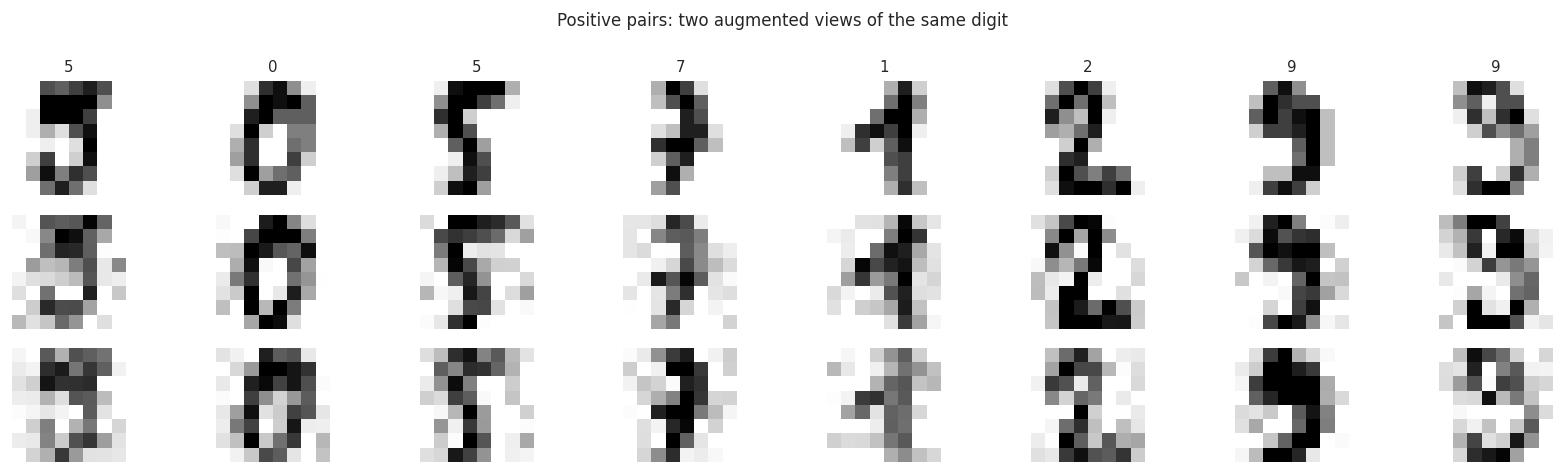

In [45]:
# Show augmented pairs for a few examples
rng_vis = torch.manual_seed(99)
X_vis   = torch.tensor(X_tr[:8], dtype=torch.float32)
v1_vis  = augment_view(X_vis, noise_std=0.15).numpy()
v2_vis  = augment_view(X_vis, noise_std=0.15).numpy()

fig, axes = plt.subplots(3, 8, figsize=(14, 4))
row_data   = [X_tr[:8], v1_vis, v2_vis]
row_labels = ['Original', 'Augmented view 1', 'Augmented view 2']

for row, (data, label) in enumerate(zip(row_data, row_labels)):
    for col in range(8):
        axes[row, col].imshow(data[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(str(y_tr[col]), fontsize=9)
    axes[row, 0].set_ylabel(label, fontsize=8)

plt.suptitle('Positive pairs: two augmented views of the same digit', fontsize=10)
plt.tight_layout()
plt.show()

### 5.4 ContrastiveEncoder

Ми **повторно використовуємо** клас `Encoder` з лабораторної роботи 12
як **backbone** (основу). Поверх нього додаємо **проекційну голівку**
(projection head) — невеликий MLP.

Важлива деталь із SimCLR: для downstream задач (лінійний зонд, t-SNE)
ми використовуємо вихід **backbone** ($z$), а **не** вихід проекційної голівки.
Голівка лише допомагає навчанню, але кінцевим представленням не є.

```
x  →  Backbone (Encoder з lab-12)  →  z (8D)       ← використовуємо для задач
                                            ↓
                                   Projection head  →  h (32D)  ← NT-Xent під час навчання
```

In [46]:
class ContrastiveEncoder(nn.Module):
    """SimCLR-style contrastive encoder: backbone + projection head.

    The backbone is the Encoder from lab 12. The projection head is a
    small 2-layer MLP used only during contrastive training.
    For downstream evaluation, use encode() — backbone output only.
    """

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int, proj_dim: int = 32):
        super().__init__()
        self.backbone  = Encoder(input_dim, hidden_dim, latent_dim)
        self.proj_head = nn.Sequential(
            nn.Linear(latent_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Backbone representation — used for evaluation and downstream tasks."""
        return self.backbone(x)

    def project(self, x: torch.Tensor) -> torch.Tensor:
        """Backbone + projection head — used only during contrastive training."""
        return self.proj_head(self.backbone(x))


def train_contrastive(
    model:       ContrastiveEncoder,
    X_train:     np.ndarray,
    n_epochs:    int   = 150,
    lr:          float = 1e-3,
    batch_size:  int   = 256,
    noise_std:   float = 0.25,
    temperature: float = 0.5,
    seed:        int   = 42,
) -> list:
    """Train ContrastiveEncoder with NT-Xent loss.

    For each batch: create two independent augmented views,
    pass both through the projection head, compute NT-Xent, backprop.
    """
    torch.manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses    = []
    model.train()

    for _ in range(n_epochs):
        epoch_loss = 0.0
        for (batch,) in loader:
            v1 = augment_view(batch, noise_std)
            v2 = augment_view(batch, noise_std)

            loss = nt_xent_loss(model.project(v1), model.project(v2), temperature)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss / len(loader))

    return losses

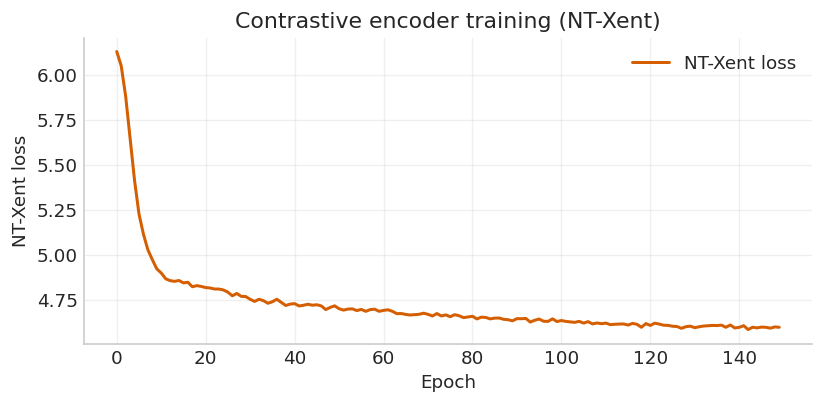

Initial : 6.1303   Final : 4.5986


In [47]:
torch.manual_seed(SEED)
cont_enc    = ContrastiveEncoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM, proj_dim=32
)
cont_losses = train_contrastive(
    cont_enc, X_tr, n_epochs=150, lr=1e-3,
    batch_size=256, noise_std=0.25, temperature=0.5, seed=SEED,
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cont_losses, color=COLORS[3], lw=1.8, label='NT-Xent loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('NT-Xent loss')
ax.set_title('Contrastive encoder training (NT-Xent)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Initial : {cont_losses[0]:.4f}   Final : {cont_losses[-1]:.4f}')

In [48]:
# Extract backbone representations (not projection head) for evaluation
cont_enc.eval()
with torch.no_grad():
    Z_cont_tr = cont_enc.encode(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    Z_cont_te = cont_enc.encode(torch.tensor(X_te, dtype=torch.float32)).numpy()

# Full linear probe comparison across all methods
print(f'{"Representation":<38} {"Train":>10}   {"Test":>8}')
print('-' * 64)
acc_raw  = linear_probe(X_tr,      X_te,      y_tr, y_te, 'Raw pixels (64D)')
acc_ae   = linear_probe(Z_ae_tr,   Z_ae_te,   y_tr, y_te, 'AE          latent z (8D)')
acc_dae  = linear_probe(Z_dae_tr,  Z_dae_te,  y_tr, y_te, 'DAE         latent z (8D)')
acc_cont = linear_probe(Z_cont_tr, Z_cont_te, y_tr, y_te, 'Contrastive latent z (8D)')

Representation                              Train       Test
----------------------------------------------------------------
Raw pixels (64D)                       train: 98.7%   test: 95.6%
AE          latent z (8D)              train: 92.2%   test: 88.9%
DAE         latent z (8D)              train: 92.1%   test: 91.4%
Contrastive latent z (8D)              train: 92.3%   test: 91.4%


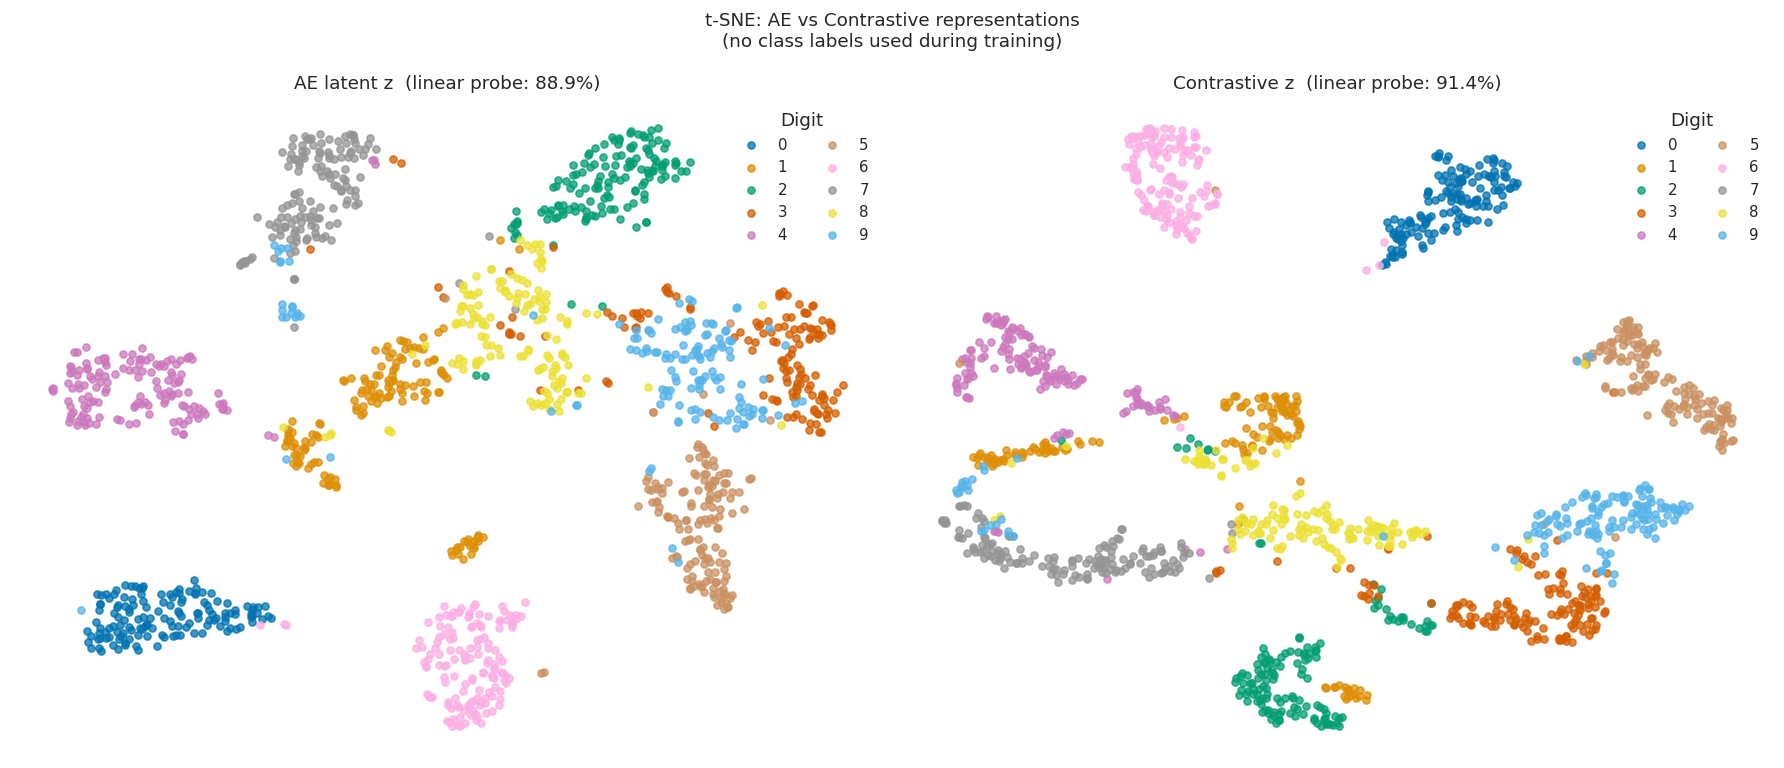

In [49]:
# Side-by-side t-SNE: AE vs Contrastive
Y_cont = TSNE(**tsne_kw).fit_transform(scaler.fit_transform(Z_cont_tr))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (Y, title) in zip(axes, [
    (Y_ae,   f'AE latent z  (linear probe: {acc_ae:.1%})'),
    (Y_cont, f'Contrastive z  (linear probe: {acc_cont:.1%})'),
]):
    for c, col in zip(range(10), COLORS):
        mask = y_tr == c
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   color=col, label=str(c), s=18, alpha=0.75)
    ax.set_title(title, fontsize=11)
    ax.legend(title='Digit', fontsize=9, ncol=2, loc='best')
    ax.axis('off')

plt.suptitle(
    't-SNE: AE vs Contrastive representations\n(no class labels used during training)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

**Ключовий висновок:** контрастивне навчання, як правило, дає **суттєво
кращі представлення**, ніж автоенкодер, попри відсутність міток.

Чому? Автоенкодер оптимізує **реконструкцію кожного пікселя** — це «легка»
задача, яка не вимагає розуміти семантичну відмінність між класами.
NT-Xent натомість явно вчить: **два погляди на ту саму цифру мають бути
ближчими одне до одного, ніж до будь-якої іншої цифри в батчі**.
Це набагато ближче до того, що потрібно для класифікації.

Саме тому контрастивне навчання стало домінуючим підходом у сучасному
self-supervised learning для зображень (SimCLR, MoCo, DINO та інші).

---
<a id='modern'></a>
## 6. Зв'язок із сучасними моделями

Всі принципи, розглянуті в цій лекції, живуть всередині найбільших
моделей сучасного AI. Різниця — у масштабі та архітектурі,
але **логіка pretext task залишається тією самою**.

| Модель | Рік | Pretext task | Принцип із цієї лекції |
|--------|-----|-------------|------------------------|
| **BERT** | 2018 | Відновити 15% замаскованих токенів | DAE застосований до тексту |
| **GPT** | 2018 | Передбачити наступний токен | Авторегресивна реконструкція |
| **SimCLR** | 2020 | Аугментована пара → близькі ембединги | NT-Xent (той самий, що вище) |
| **MoCo** | 2020 | Queue of negatives + momentum encoder | Контрастивне навчання |
| **CLIP** | 2021 | Пара (зображення, підпис) → близькі ембединги | NT-Xent між модальностями |
| **DINO** | 2021 | Self-distillation: дві crops → однаковий вихід | Bootstrapped contrastive |
| **MAE** | 2021 | Відновити 75% замаскованих патчів | DAE для зображень |

### 6.1 BERT — DAE для мови

```
Input:  "The [MASK] sat on the [MASK]."
Target: "cat", "mat"
Loss:   cross-entropy на замаскованих позиціях
```

Маскування у BERT — це навмисне ушкодження входу;
реконструкція — pretext task. Замість пікселів — токени;
замість MSE — cross-entropy; замість FC-шарів — трансформер.
**Принцип DAE залишається незмінним**.

### 6.2 CLIP — NT-Xent між зображенням і текстом

CLIP навчається на 400M пар (зображення, підпис) з Інтернету.
Pretext task: зображення та його підпис мають мати **близькі ембединги**;
зображення та будь-який інший підпис — далекі.

```
Позитивна пара: (фото кота, "a photo of a cat")
Негативна пара: (фото кота, "a photo of a dog")
Loss:           NT-Xent — той самий, що ми реалізували вище
```

Результат: модель розуміє спільний простір зображень і тексту,
і здатна класифікувати зображення «zero-shot» — без жодного
додаткового навчання.

### 6.3 Чому self-supervised виграє у масштабі

Scaling law для self-supervised моделей: більше нерозмічених даних →
краще представлення → краще downstream performance. Мітки завжди
залишаються вузьким місцем. Саме тому GPT-4, Gemini, Claude —
всі навчені насамперед на **нерозмічених** текстових корпусах за
принципом «передбачення наступного токена», а не на розмічених датасетах.

---
<a id='summary'></a>
## 7. Підсумок

На цій лекції ми розглянули чотири способи навчатися без міток,
об'єднані одним принципом: **знайти або сконструювати сигнал із
структури самих даних**.

| Метод | Pretext task | Що отримуємо |
|-------|-------------|--------------|
| **Autoencoder** | Реконструюй вхід | Компактне представлення $z$ |
| **Denoising AE** | Відновити $x$ із $\tilde{x} = x + \varepsilon$ | Робустне представлення $z$ |
| **Self-Training** | Впевнені передбачення стають мітками | Розширена тренувальна вибірка |
| **Contrastive** | Два погляди → схожі ембединги | Семантично організований простір |

### Практичні рекомендації

- **Великий нерозмічений датасет + трохи міток** → pre-train
  contrastive encoder, fine-tune на мітках; або self-training на
  класифікаторі.
- **Потрібна robustness до шуму / пропущених значень** → DAE.
- **Простий baseline без PyTorch** → autoencoder + linear probe дає
  прийнятну точність.
- **Зображення або текст із складною семантикою** → contrastive learning
  або готова pre-trained модель (CLIP, BERT).

### Ключові ідеї для запам'ятовування

1. **Pretext task** — штучна задача, відповідь на яку генерується
   автоматично з даних. Розв'язуючи її, модель вивчає корисне представлення.
2. **Складніший pretext task** як правило дає кращі представлення:
   DAE > AE; contrastive > DAE для семантичних задач.
3. **Self-training** — міст між unsupervised і supervised: ітеративно
   розширює набір «міток» через впевнені передбачення моделі.
4. **NT-Xent loss** — та сама ідея, що лежить в основі BERT, CLIP, GPT:
   ефективне навчання на мільярдах нерозмічених прикладів.